# Settings

In [1]:
alpha = 0.05 

In [2]:
def underline(txt: str) -> str:
    """Return *txt* underlined for terminals that support ANSI codes."""
    return f"\033[4m{txt}\033[0m"

def bold(txt: str) -> str:
    """Return *txt* wrapped in the ANSI code for bold (bright) text."""
    return f"\033[1m{txt}\033[0m"

Loading the Study Results into a Dataframe: 

In [3]:
from Study import participants
from HelperFunctions.get_data import get_data

df = get_data(participants=participants, task_ids=[i for i in range(1,18)])
df["id"] = df["id"].apply(lambda x: x.replace("task_", "")).astype(int)

Does not know what IF is, question skipped after trying to figure it out skipped
Skipped, too complicated skipped
Skipped, too complicated skipped
Skipped, doesn't know max skipped
Participant found the -1 confusing, skipped skipped
Did not understand, skipped skipped
Participant was overwhelmed, skipped the question skipped
Participant did not understand, skipped  skipped


-> the data frame includes the columns: 
- "id" for the task id
- "participant" for the participants IDs
- the measured "TTU"
- the measured "DOU"
- information about the tasks content 

# 1. DOU

In [4]:
df_notone = df[df["DOU"] != 1.0]
print(f"❗ Es gibt nur {df_notone.shape[0]} von {df.shape[0]} DOU-Werten, die nicht 1.0 sind.")
print(f"→ Das sind {100 * (1 - df_notone.shape[0] / df.shape[0]):.1f}% = 1.0")

❗ Es gibt nur 110 von 357 DOU-Werten, die nicht 1.0 sind.
→ Das sind 69.2% = 1.0


# 2. TTU (task-wise) 

In [5]:
import numpy as np
import pandas as pd
import pingouin as pg
from statsmodels.stats.multitest import multipletests

def testing_task(df:pd.Dataframe, task_id:int): 
    df_task = df[df["id"] == task_id].copy()

    assert df_task["group"].nunique() == 3
    assert df_task.groupby("group").size().min() >= 2

    df_task["TTU_log"] = np.log(df_task["TTU"])

    # ANOVA mit log(TTU)
    anova_result = pg.anova(data=df_task, dv="TTU_log", between="group", detailed=True)
    p_anova = anova_result["p_unc"].iloc[0]
    anova_sig = "Significant" if p_anova < alpha else "Not significant"

    # Kruskal-Wallis mit Original-TTU
    kruskal_result = pg.kruskal(data=df_task, dv="TTU", between="group")
    p_kruskal = kruskal_result["p_unc"].iloc[0]
    kruskal_sig = "Significant" if p_kruskal < alpha else "Not significant"

    # Statistiken
    group_stats = df_task.groupby("group")["TTU"].agg(["mean", "median", "std", "count"]).round(3)
    mean_orig = group_stats["mean"].to_dict()
    median_orig = group_stats["median"].to_dict()
    std_orig = group_stats["std"].to_dict()

    print(f"\nTask {task_id:2d}:")
    print(f"   → ANOVA (log): p = {p_anova:.4f} ({anova_sig})")
    print(f"   → Kruskal-Wallis: p = {p_kruskal:.4f} ({kruskal_sig})")
    print(f"   → Mean (TTU): {mean_orig}")
    print(f"   → Mediane (TTU): {median_orig}")
    print(f"   → Std-Abw. (TTU): {std_orig}")

    return {
        "task_id": task_id,
        "p_anova": p_anova,
        "p_kruskal": p_kruskal,
        "anova_sig": anova_sig,
        "kruskal_sig": kruskal_sig,
        "median_TTU": median_orig,
        "mean_TTU": mean_orig,
        "std_TTU": std_orig
    }

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def box_plot_per_task(df:pd.Dataframe, task_id:int):
    df_task = df[df["id"] == task_id]
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_task, x="group", y="TTU")
    plt.title(f"Task {task_id}: TTU (Original) nach Gruppen")
    plt.ylabel("Bearbeitungszeit (s)")
    plt.show()

In [11]:
results = []

for task_id in range(1,18): 
    results.append( 
        testing_task(df=df, task_id=task_id)
    )


Task  1:
   → ANOVA (log): p = 0.5340 (Not significant)
   → Kruskal-Wallis: p = 0.4850 (Not significant)
   → Mean (TTU): {'Dynamic sketch construction': 32.0, 'Formula construction': 32.571, 'Static sketch construction': 25.714}
   → Mediane (TTU): {'Dynamic sketch construction': 26.0, 'Formula construction': 23.0, 'Static sketch construction': 24.0}
   → Std-Abw. (TTU): {'Dynamic sketch construction': 14.376, 'Formula construction': 26.974, 'Static sketch construction': 17.114}

Task  2:
   → ANOVA (log): p = 0.0345 (Significant)
   → Kruskal-Wallis: p = 0.0685 (Not significant)
   → Mean (TTU): {'Dynamic sketch construction': 22.571, 'Formula construction': 18.714, 'Static sketch construction': 14.0}
   → Mediane (TTU): {'Dynamic sketch construction': 21.0, 'Formula construction': 16.0, 'Static sketch construction': 14.0}
   → Std-Abw. (TTU): {'Dynamic sketch construction': 6.949, 'Formula construction': 5.469, 'Static sketch construction': 6.298}

Task  3:
   → ANOVA (log): p = 0

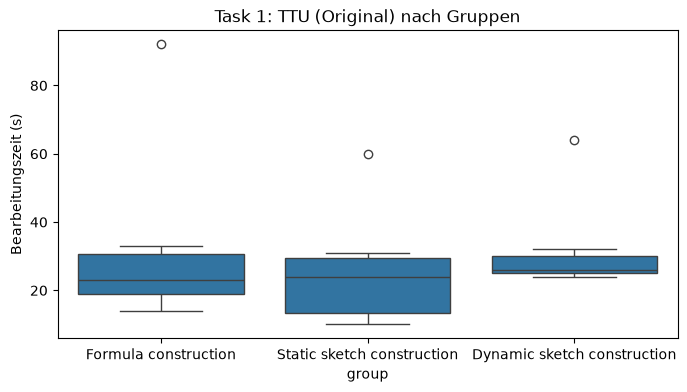

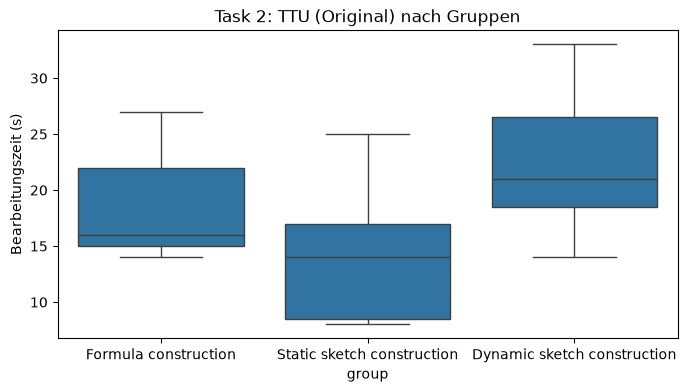

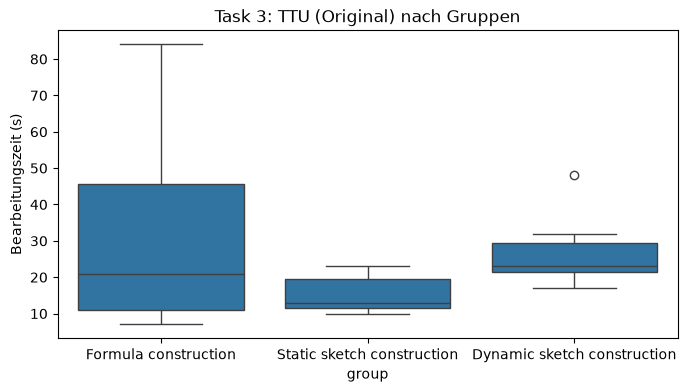

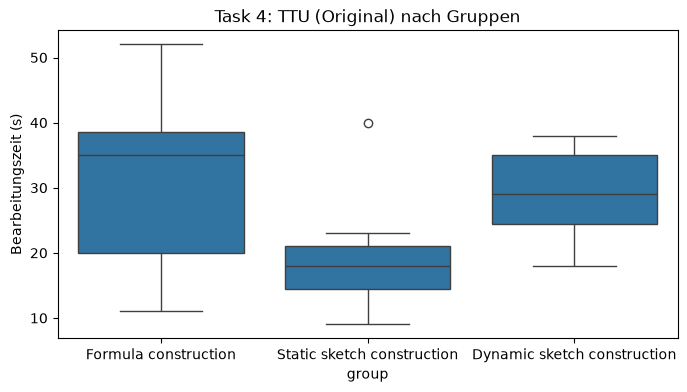

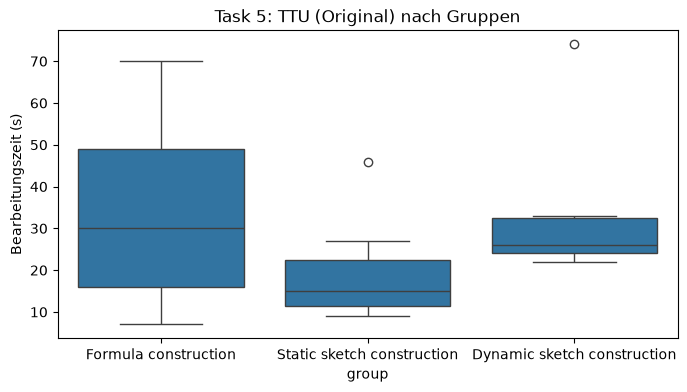

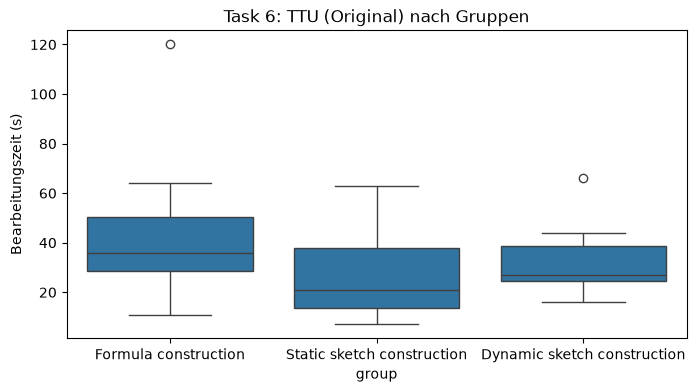

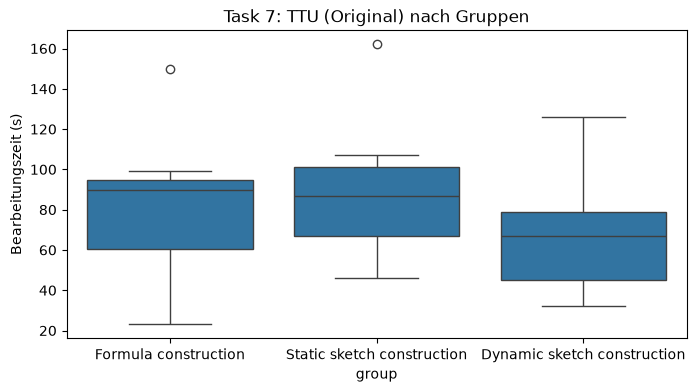

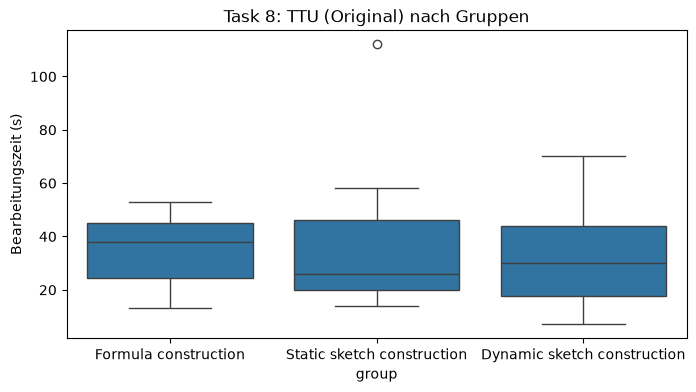

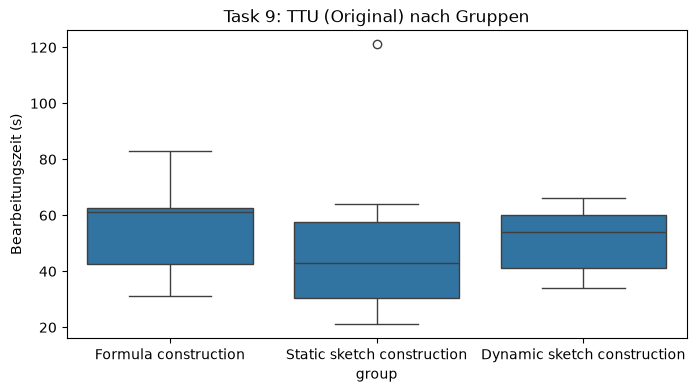

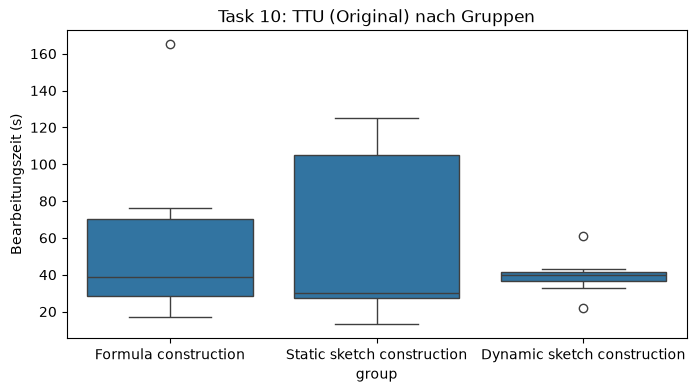

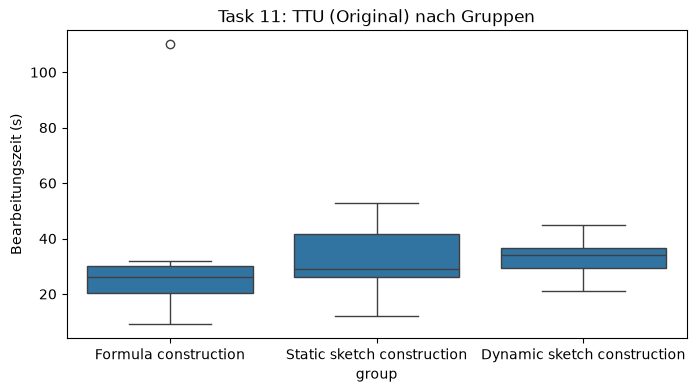

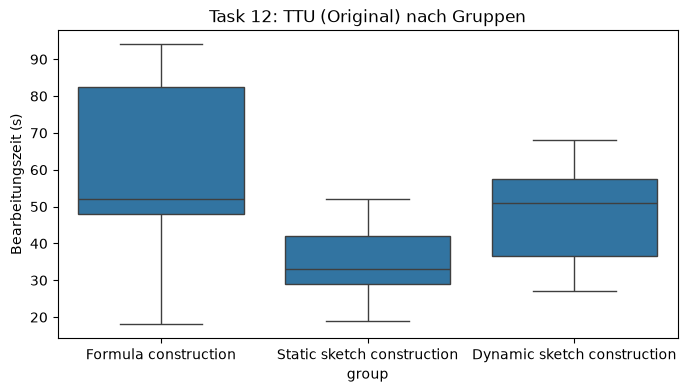

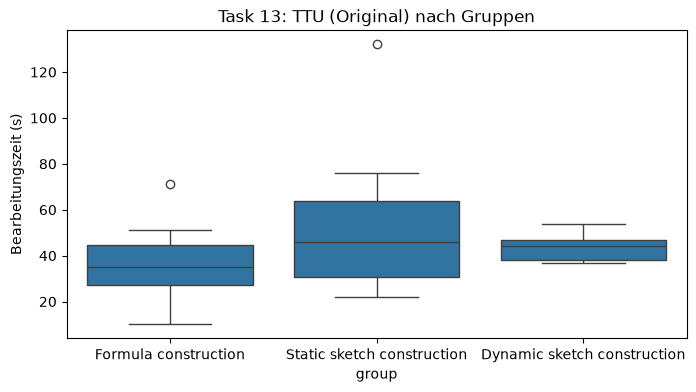

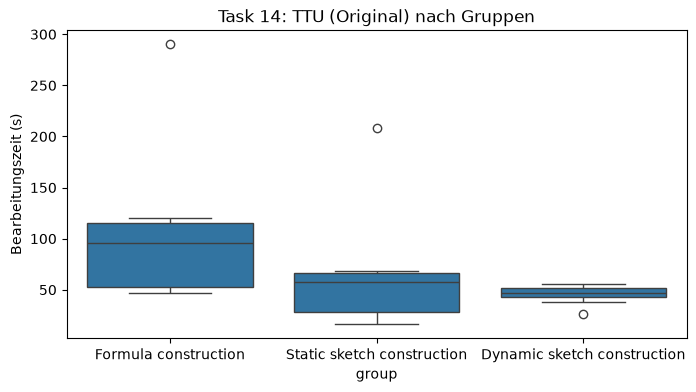

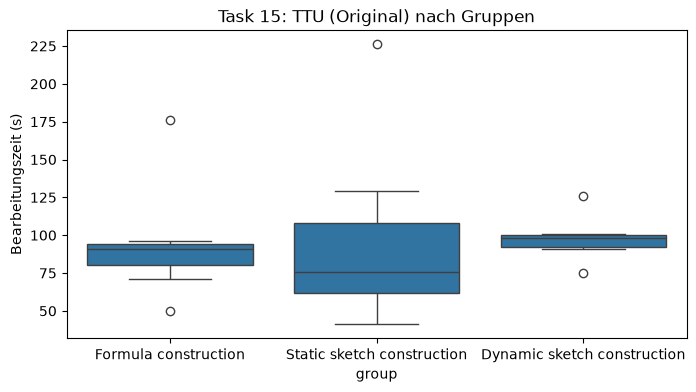

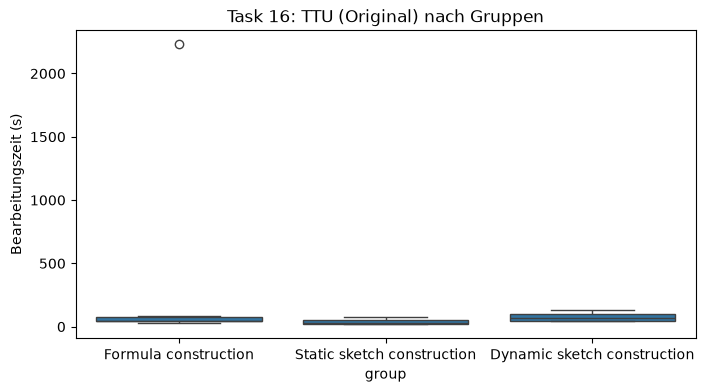

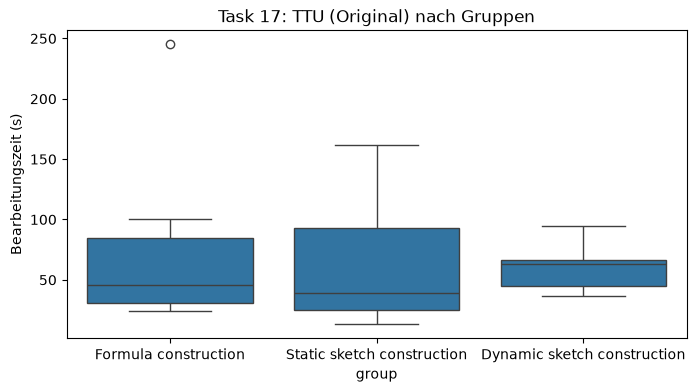

In [10]:
for task_id in range(1,18): 
    box_plot_per_task(df=df, task_id=task_id)